In [21]:
from astropy.io import fits
import numpy as np
from astropy.table import Table
import pandas as pd
import glob
from astropy.table import vstack
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages

In [22]:
df = pd.read_csv("../PN_candidates/PNe-Halpha_emitter_wise_group4-simbad-candidates.csv")
len(df)

30

In [23]:
df_mask = df[df["grouped_class"] =="LongPeriodV*"]
df_mask

KeyError: 'grouped_class'

In [ ]:
# Define the true objective function
def objective(x, a, b):
    return a * x + b

# Definition for the colors
def colour(table, f1, f2, f3, f4):
    xcolour = table[f1] - table[f2]
    ycolour = table[f3] - table[f4]
    return xcolour, ycolour

In [24]:
# Creating the color to creating the diagram 
cx, cy = colour(df, "W1mag", "W2mag", "rImag", "Hamag")

In [25]:
cx1, cy1 = colour(df, 'gmag', 'rImag', 'Hmag', 'W1mag')

In [26]:
x_new = np.linspace(-15.5, 15,  200)
y = -0.5392*x_new + 1.8268
yy = -7*x_new + 23.5
#Mask
#mask = y >= result_y - 0.5
#ax.plot(x_new, yy , color='k', linestyle='-.')

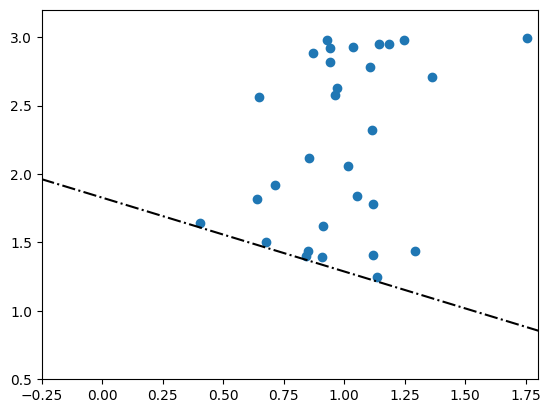

In [27]:
plt.plot(cx, cy, "o")
plt.plot(x_new, y, color='k', linestyle='-.')
plt.xlim(-0.25, 1.8)
plt.ylim(0.5, 3.2)
plt.show()

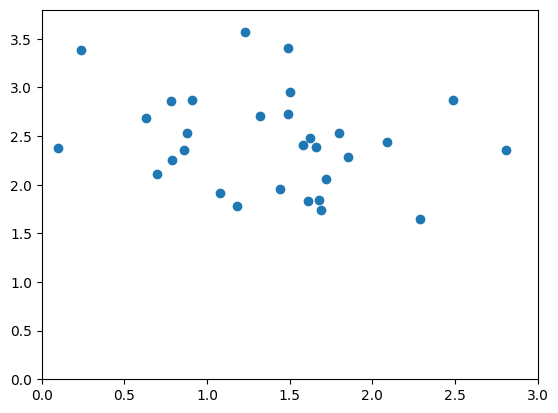

In [28]:
plt.plot(cx1, cy1, "o")
#plt.plot(x_new, y, color='k', linestyle='-.')
plt.xlim(0, 3)
plt.ylim(0, 3.8)
plt.show()

In [29]:
#creating colors

df["r_Ha"] = df["rImag"] - df["Hamag"]
df["g_Ha"] = df["gmag"] - df["Hamag"]
df["i_Ha"] = df["imag"] - df["Hamag"]
df["W1_W2"] = df["W1mag"] - df["W2mag"]
df["J_H"] = df["Jmag"] - df["Hmag"]
df["H_W2"] = df["Hmag"] - df["W2mag"]
df["J_W2"] = df["Jmag"] - df["W2mag"]
df["g_r"] = df["gmag"] - df["rImag"]
df["g_W1"] = df["gmag"] - df["W1mag"]
df["g_W2"] = df["gmag"] - df["W2mag"]
df["r_W1"] = df["rImag"] - df["W1mag"]
df["r_W2"] = df["rImag"] - df["W2mag"]
df["g_H"] = df["gmag"] - df["Hmag"]
df["g_J"] = df["gmag"] - df["Jmag"]
df["r_H"] = df["rImag"] - df["Hmag"]
df["r_J"] = df["rImag"] - df["Jmag"]

In [30]:

# 1. Crear mapeo de colores original
original_classes = df['main_type'].unique()
original_palette = sns.color_palette("husl", n_colors=len(original_classes))
original_color_dict = dict(zip(original_classes, original_palette))

In [31]:
# Clases SIMBAD en el Grupo 4
classes = df["main_type"].unique()

In [32]:
# Paleta de colores para cada clase
palette = sns.color_palette("husl", n_colors=len(classes))

In [33]:
# 2. Crear nueva columna con agrupaciones específicas
df['grouped_class'] = np.select(
    [
        df['main_type'].str.contains('YSO|TTauri')     # Grupo 2
    ],
    [
        'YSO_TTauri_Group'     # Clase unificada para YSO/TTauri y candidatos
    ],
    default=df['main_type']  # Clases no modificadas
)


In [34]:
# 3. Definir paleta de marcadores SOLO RELLENOS
unique_classes = df['grouped_class'].unique()
markers = ['o', 's', '^', 'D', '*', 'o', 'P', 'X', 'h', 'H', 'p']  # 10 marcadores rellenos
marker_dict = dict(zip(unique_classes, markers[:len(unique_classes)]))

In [35]:
# 4. Crear paleta de colores para clases agrupadas
grouped_color_dict = {}

for cls in unique_classes:
    if cls == 'YSO_TTauri_Group':
        grouped_color_dict[cls] = original_color_dict['YSO']
    else:
        grouped_color_dict[cls] = original_color_dict[cls]


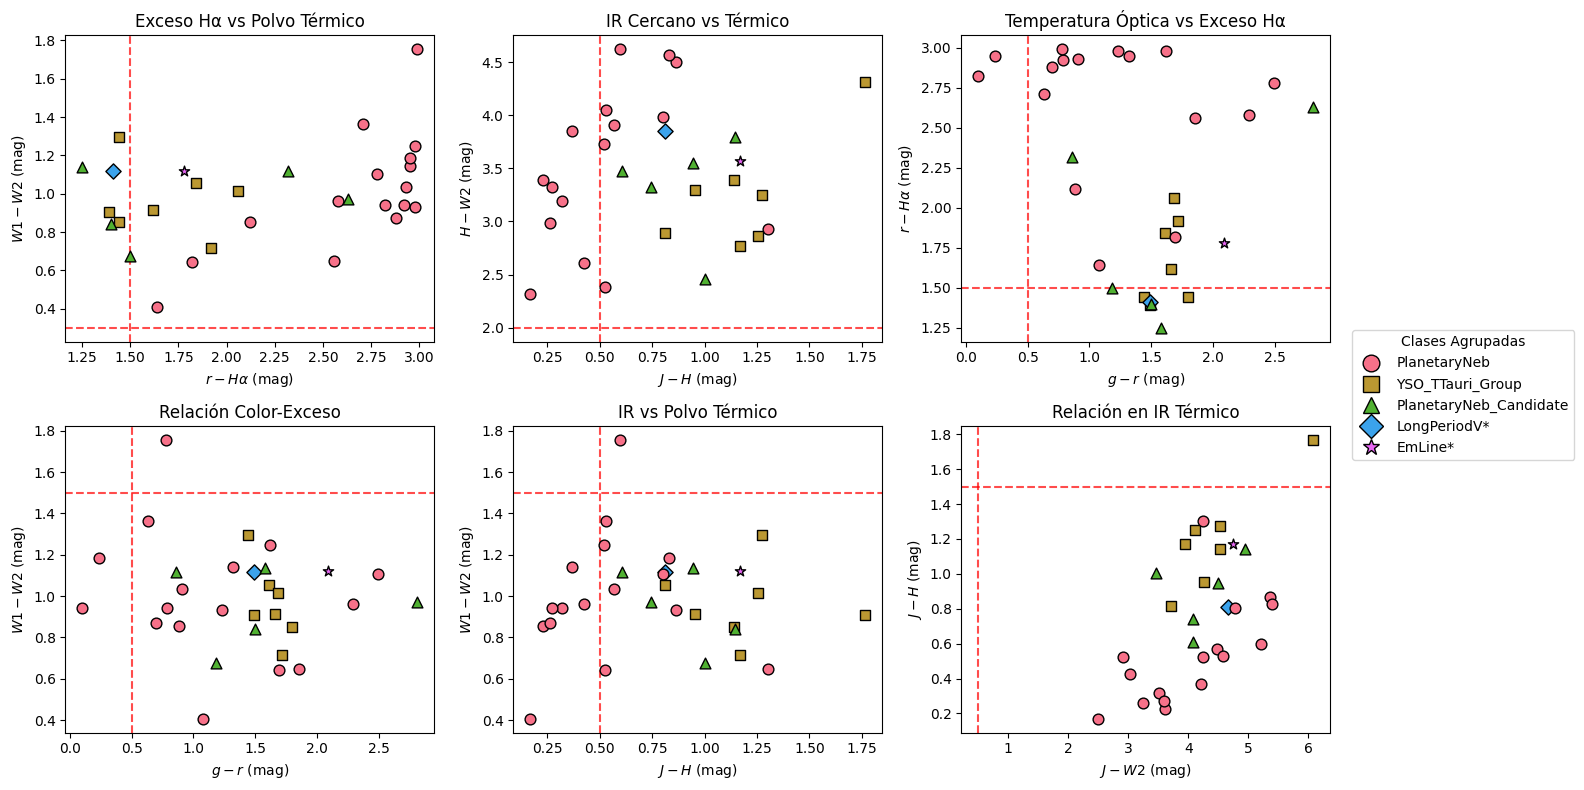

In [36]:
# 2. Crear subplots en formato 2x3
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

# 3. Añadir líneas guía según posición
for i, ax in enumerate(axes):
    if i == 0:
        ax.axvline(1.5, color='red', linestyle='--', alpha=0.7, zorder=1)
        ax.axhline(0.3, color='red', linestyle='--', alpha=0.7, zorder=1)
    elif i == 1:
        ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, zorder=1)
        ax.axhline(2.0, color='red', linestyle='--', alpha=0.7, zorder=1)
    else:
        ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, zorder=1)
        ax.axhline(1.5, color='red', linestyle='--', alpha=0.7, zorder=1)

# 4. Función corregida para graficar con zorder personalizado
def plot_with_zorder(ax, x, y, grouped_classes, color_dict, marker_dict, data):
    for cls in grouped_classes:
        subset = data[data['grouped_class'] == cls]
        # Solo estas dos clases encima
        if cls in ['PlanetaryNeb', 'PlanetaryNeb_Candidate']:
            z = 3
        else:
            z = 2
        ax.scatter(
            subset[x], subset[y],
            color=color_dict[cls],
            marker=marker_dict[cls],
            s=60,
            edgecolor='black',
            label=cls,
            zorder=z
        )

# 5. Graficar cada diagrama
# Diagrama 1
plot_with_zorder(axes[0], "r_Ha", "W1_W2", unique_classes,
                 grouped_color_dict, marker_dict, df)
axes[0].set(xlabel=r"$r - H\alpha$ (mag)",
            ylabel=r"$W1 - W2$ (mag)",
            title="Exceso Hα vs Polvo Térmico")

# Diagrama 2
plot_with_zorder(axes[1], "J_H", "H_W2", unique_classes,
                 grouped_color_dict, marker_dict, df)
axes[1].set(xlabel=r"$J - H$ (mag)",
            ylabel=r"$H - W2$ (mag)",
            title="IR Cercano vs Térmico")

# Diagrama 3
plot_with_zorder(axes[2], "g_r", "r_Ha", unique_classes,
                 grouped_color_dict, marker_dict, df)
axes[2].set(xlabel=r"$g - r$ (mag)",
            ylabel=r"$r - H\alpha$ (mag)",
            title="Temperatura Óptica vs Exceso Hα")

# Diagrama 4
plot_with_zorder(axes[3], "g_r", "W1_W2", unique_classes,
                 grouped_color_dict, marker_dict, df)
axes[3].set(xlabel=r"$g - r$ (mag)",
            ylabel=r"$W1 - W2$ (mag)",
            title="Relación Color-Exceso")

# Diagrama 5
plot_with_zorder(axes[4], "J_H", "W1_W2", unique_classes,
                 grouped_color_dict, marker_dict, df)
axes[4].set(xlabel=r"$J - H$ (mag)",
            ylabel=r"$W1 - W2$ (mag)",
            title="IR vs Polvo Térmico")

# Diagrama 6
plot_with_zorder(axes[5], "J_W2", "J_H", unique_classes,
                 grouped_color_dict, marker_dict, df)
axes[5].set(xlabel=r"$J - W2$ (mag)",
            ylabel=r"$J - H$ (mag)",
            title="Relación en IR Térmico")

# 6. Leyenda única
legend_elements = [
    Line2D([0], [0],
           marker=marker_dict[cls],
           color='w',
           markerfacecolor=grouped_color_dict[cls],
           markersize=12,
           markeredgecolor='black',
           label=cls,
           linestyle='None')
    for cls in unique_classes
]
fig.legend(handles=legend_elements,
           title="Clases Agrupadas",
           bbox_to_anchor=(0.75, 0.5),
           loc='center left',
           frameon=True)

# 7. Ajustes finales
plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.show()

In [37]:
def simad_type(Path, file_):
    df = pd.read_csv(Path + file_)
    print(file_.split("emitter_")[-1].split("-sim")[0], ", Number of object:", len(df))
    dict_simbad_ = df["main_type"].value_counts().to_dict()
    return dict_simbad_

In [38]:
g4_pn = simad_type("../PN_candidates/", "PNe-Halpha_emitter_wise_group4-simbad-candidates.csv")
g4_pn

wise_group4 , Number of object: 30


{'PlanetaryNeb': 16,
 'YSO': 6,
 'PlanetaryNeb_Candidate': 5,
 'TTauri*': 1,
 'LongPeriodV*': 1,
 'EmLine*': 1}